> ⚠️ ⚠️ ⚠️ **NB THIS IS ALL MESENCHYMAL CELLS** ⚠️⚠️⚠️

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import UnivariateSpline
from scipy.stats import linregress
import warnings
from math import ceil
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100
plt.rcParams['pdf.fonttype'] = 42

## 1. Load Data

In [2]:
# Load results and metadata
pb_meta = pd.read_csv("/nfs/team292/vl6/Endometriosis/Xenium/xenium_mesenchymal_pb_meta.tsv", sep="\t")
pb_matrix = pd.read_csv("/nfs/team292/vl6/Endometriosis/Xenium/xenium_mesenchymal_pb_matrix.tsv", sep="\t", index_col=0)

print(f"\nMetadata shape: {pb_meta.shape}")
print(f"Count matrix shape: {pb_matrix.shape}")


Metadata shape: (56, 5)
Count matrix shape: (480, 56)


In [3]:
pb_meta.columns

Index(['sample', 'binned_compartments', 'binned_compartments_ordered',
       'menstrual_phase', 'n_cells'],
      dtype='object')

In [4]:
# Drop bins with fewer than 10 cells
n_before = len(pb_meta)
pb_meta = pb_meta[pb_meta['n_cells'] >= 10].reset_index(drop=True)
print(f"Dropped {n_before - len(pb_meta)} bins with < 10 cells ({len(pb_meta)} remaining)")

Dropped 0 bins with < 10 cells (56 remaining)


In [5]:
pb_meta.head()

,sample,binned_compartments,binned_compartments_ordered,menstrual_phase,n_cells
0,A13,basalis_1,1,Proliferative,38629
1,A13,basalis_2,2,Proliferative,26044
2,A13,functionalis_1,3,Proliferative,42751
3,A13,functionalis_2,4,Proliferative,25965
4,A13,functionalis_3,5,Proliferative,21894


In [6]:
pb_meta[
    pb_meta['menstrual_phase'] == 'Menstrual'
]['sample'].value_counts()

sample
DA39_S8b    6
DA50        5
DA63        5
Name: count, dtype: int64

## 2. Prepare Data for Visualization

In [7]:
# Normalize counts to CPM (counts per million)
lib_sizes = pb_matrix.sum(axis=0).values
cpm_matrix = (pb_matrix / lib_sizes * 1e6)
log2_cpm_matrix = np.log2(cpm_matrix + 1)  # Add pseudocount

# Menstrual phase colors
phase_colors = {
    'Proliferative': 'forestgreen',
    'Secretory': 'yellowgreen',
    'Menstrual': 'darkorange',
    'Hormones': 'turquoise'
}

# Phase order
phase_order = ['Proliferative', 'Secretory', 'Menstrual', 'Hormones']

# Categorical binned_compartments order
binned_compartments_order = ['basalis_1', 'basalis_2', 'functionalis_1', 'functionalis_2', 'functionalis_3', 'lumen_1']

# Sort metadata by categorical binned_compartments order
pb_meta['binned_compartments'] = pd.Categorical(pb_meta['binned_compartments'], categories=binned_compartments_order, ordered=True)
pb_meta = pb_meta.sort_values('binned_compartments').reset_index(drop=True)

# Reorder expression matrices to match sorted metadata
meta_col_names = pb_meta['sample'] + '_bin' + pb_meta['binned_compartments_ordered'].astype(str) + '_' + pb_meta['binned_compartments'].astype(str)
cpm_matrix = cpm_matrix[meta_col_names]
log2_cpm_matrix = log2_cpm_matrix[meta_col_names]

# Rename columns to simple sample_compartment for downstream use
simple_col_names = pb_meta['sample'] + '_' + pb_meta['binned_compartments'].astype(str)
cpm_matrix.columns = simple_col_names
log2_cpm_matrix.columns = simple_col_names

print(f"CPM matrix shape: {cpm_matrix.shape}")
print(f"\nAxis bin order: {pb_meta['binned_compartments'].unique().tolist()}")
print(f"Column names aligned: {all(simple_col_names == cpm_matrix.columns)}")

CPM matrix shape: (480, 56)

Axis bin order: ['basalis_1', 'basalis_2', 'functionalis_1', 'functionalis_2', 'functionalis_3', 'lumen_1']
Column names aligned: True


In [8]:
# ## Donor filter
# # Set selected_donors to a list of donor IDs to restrict plots to those donors.
# # Set to None (or leave as an empty list) to use all donors.

# print("Available donors:")
# for d in sorted(pb_meta['sample'].unique()):
#     phase = pb_meta.loc[pb_meta['sample'] == d, 'menstrual_phase'].iloc[0]
#     print(f"  {d!r}  ({phase})")

## 3. Define Plotting Function

In [9]:
ft_samples = ['A13', 'A14', 'A16', 'A17', 'A22', 'D1', 'D2', 'D3', 'D4', 'D5', 'D7']

binned_compartments_order = [
    'basalis_1', 'basalis_2',
    'functionalis_1', 'functionalis_2', 'functionalis_3',
    'lumen_1'
]

def plot_gene_trend(gene_name, pb_meta, log2_cpm_matrix,
                    phase_colors, phase_order, n_grid=100, smooth_factor=0.5,
                    k=2, ncols=3, filter_to_full_thickness=False,
                    add_ci=False, ci=95, n_boot=500, random_state=0, stages = None, save = None):
    
    # ── optionally filter stages ────────────────────────

    if stages is not None:
        stages_mask = pb_meta['menstrual_phase'].isin(stages)
        pb_meta = pb_meta[stages_mask].reset_index(drop=True)
        st_cols = pb_meta['sample'] + '_' + pb_meta['binned_compartments'].astype(str)
        log2_cpm_matrix = log2_cpm_matrix[st_cols]
    

    # ── optionally restrict to full-thickness donors ────────────────────────
    if filter_to_full_thickness:
        ft_mask = pb_meta['sample'].isin(ft_samples)
        pb_meta = pb_meta[ft_mask].reset_index(drop=True)
        ft_cols = pb_meta['sample'] + '_' + pb_meta['binned_compartments'].astype(str)
        log2_cpm_matrix = log2_cpm_matrix[ft_cols]

    # ── build numeric encoding for categorical binned_compartments ─────────────────────
    present_bins = [b for b in binned_compartments_order if b in pb_meta['binned_compartments'].values]
    bin_to_int = {b: i for i, b in enumerate(present_bins)}

    pb_meta = pb_meta.copy()
    pb_meta['binned_compartments_int'] = pb_meta['binned_compartments'].map(bin_to_int)

    axis_int_min = 0
    axis_int_max = len(present_bins) - 1
    axis_grid_int = np.linspace(axis_int_min, axis_int_max, n_grid)

    tick_positions = list(range(len(present_bins)))
    tick_labels = present_bins

    rng = np.random.default_rng(random_state)

    # ── helper that draws a single gene onto a given Axes ───────────────────
    def _plot_single(gene, ax):
        if gene not in log2_cpm_matrix.index:
            ax.text(
                0.5, 0.5, f"'{gene}'\nnot found",
                ha='center', va='center',
                transform=ax.transAxes,
                color='red'
            )
            ax.set_title(gene)
            return

        expr = log2_cpm_matrix.loc[gene].values

        for phase in phase_order:
            phase_mask = pb_meta['menstrual_phase'] == phase
            phase_indices = np.where(phase_mask.values)[0]

            if len(phase_indices) == 0:
                continue

            phase_axis_int = pb_meta.loc[phase_mask, 'binned_compartments_int'].values
            phase_expr = expr[phase_indices]

            ax.scatter(
                phase_axis_int,
                phase_expr,
                color=phase_colors[phase],
                s=8,
                alpha=0.5,
                label=phase,
                edgecolor='black',
                linewidth=0.5
            )

            import pandas as _pd

            bin_means = (
                _pd.Series(phase_expr, index=phase_axis_int)
                .groupby(level=0)
                .mean()
                .sort_index()
            )

            x_fit = bin_means.index.values.astype(float)
            y_fit = bin_means.values

            if len(x_fit) > 3:
                try:
                    spline = UnivariateSpline(
                        x_fit,
                        y_fit,
                        s=smooth_factor * len(x_fit),
                        k=min(k, len(x_fit) - 1)
                    )

                    smooth_expr = spline(axis_grid_int)

                    ax.plot(
                        axis_grid_int,
                        smooth_expr,
                        color=phase_colors[phase],
                        linewidth=2.5,
                        linestyle='-'
                    )

                    # ── optional bootstrapped CI around spline ───────────────
                    if add_ci:
                        phase_df = _pd.DataFrame({
                            "x": phase_axis_int.astype(float),
                            "y": phase_expr
                        })

                        boot_curves = []

                        for _ in range(n_boot):
                            boot_idx = rng.integers(
                                0,
                                len(phase_df),
                                size=len(phase_df)
                            )
                            boot_df = phase_df.iloc[boot_idx]

                            boot_means = (
                                boot_df
                                .groupby("x")["y"]
                                .mean()
                                .sort_index()
                            )

                            x_boot = boot_means.index.values.astype(float)
                            y_boot = boot_means.values

                            if len(x_boot) > k:
                                try:
                                    boot_spline = UnivariateSpline(
                                        x_boot,
                                        y_boot,
                                        s=smooth_factor * len(x_boot),
                                        k=min(k, len(x_boot) - 1)
                                    )

                                    boot_curves.append(
                                        boot_spline(axis_grid_int)
                                    )
                                except Exception:
                                    pass

                        if len(boot_curves) > 10:
                            boot_curves = np.vstack(boot_curves)

                            alpha = (100 - ci) / 2
                            lower = np.nanpercentile(
                                boot_curves,
                                alpha,
                                axis=0
                            )
                            upper = np.nanpercentile(
                                boot_curves,
                                100 - alpha,
                                axis=0
                            )

                            ax.fill_between(
                                axis_grid_int,
                                lower,
                                upper,
                                color=phase_colors[phase],
                                alpha=0.18,
                                linewidth=0
                            )

                except Exception:
                    try:
                        slope, intercept, _, _, _ = linregress(x_fit, y_fit)

                        ax.plot(
                            axis_grid_int,
                            slope * axis_grid_int + intercept,
                            color=phase_colors[phase],
                            linewidth=2.5,
                            linestyle='--'
                        )
                    except Exception:
                        pass

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=35, ha='right', fontsize=9)
        ax.set_xlabel('Basalis → Luminal Axis')
        ax.set_ylabel('log2-CPM')
        ax.set_title(gene, fontsize=12)
        ax.legend(loc='best', frameon=True, fontsize=10)
        ax.grid(True, alpha=0.2)

    # ── single-gene path ────────────────────────────────────────────────────
    if isinstance(gene_name, str):
        fig, ax = plt.subplots(figsize=(4, 4))
        _plot_single(gene_name, ax)
        plt.tight_layout()
        return fig

    # ── multi-gene grid path ────────────────────────────────────────────────
    genes = list(gene_name)
    n = len(genes)
    ncols = min(ncols, n)
    nrows = ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, 4 * nrows),
        squeeze=False
    )

    for i, gene in enumerate(genes):
        row, col = divmod(i, ncols)
        _plot_single(gene, axes[row][col])

    for j in range(n, nrows * ncols):
        row, col = divmod(j, ncols)
        axes[row][col].set_visible(False)

    if save:
        plt.savefig(save)

    plt.tight_layout()
    return fig

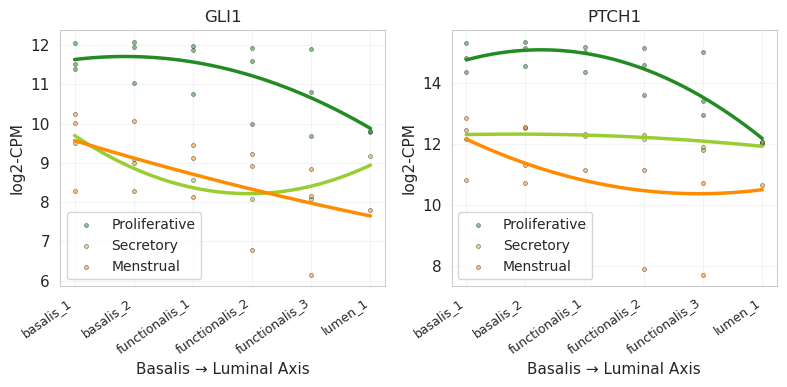

In [15]:
plot_gene_trend(['GLI1', 'PTCH1'], 
                pb_meta, log2_cpm_matrix, 
                phase_colors, phase_order, stages = ['Menstrual', 'Proliferative', 'Secretory'], save = 'sfrp5_xenium.pdf')
plt.savefig("hh_mesen_xenium.pdf")
plt.show()

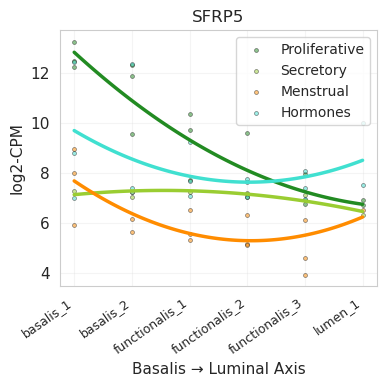

In [13]:
plot_gene_trend('SFRP5', pb_meta, log2_cpm_matrix, phase_colors, phase_order, save = 'sfrp5_xenium.pdf')
plt.savefig("sfrp5_xenium.pdf")
plt.show()